In [2]:
import pandas as pd
data = {
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 35],
    "Salary": [50000, 60000, 70000]
}
df = pd.DataFrame(data)
print(df)

      Name  Age  Salary
0    Alice   25   50000
1      Bob   30   60000
2  Charlie   35   70000


In [3]:
df.describe()

,Age,Salary
count,3.0,3.0
mean,30.0,60000.0
std,5.0,10000.0
min,25.0,50000.0
25%,27.5,55000.0
50%,30.0,60000.0
75%,32.5,65000.0
max,35.0,70000.0


In [4]:
import yfinance as yf

df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
print(df.shape)

[*********************100%***********************]  1 of 1 completed

(1006, 5)


In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201393,72.239927,70.503531,70.753999,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


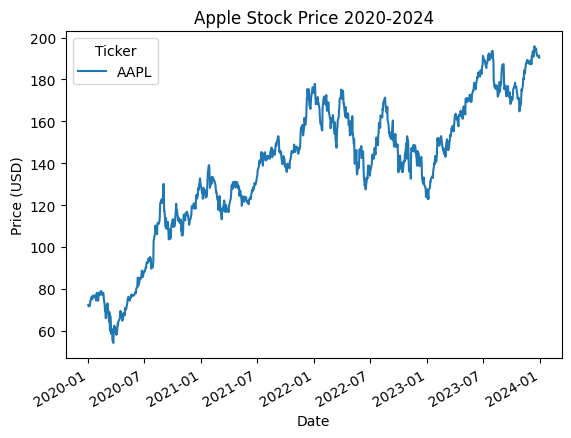

In [6]:
import matplotlib.pyplot as plt

df["Close"].plot()
plt.title("Apple Stock Price 2020-2024")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.show()

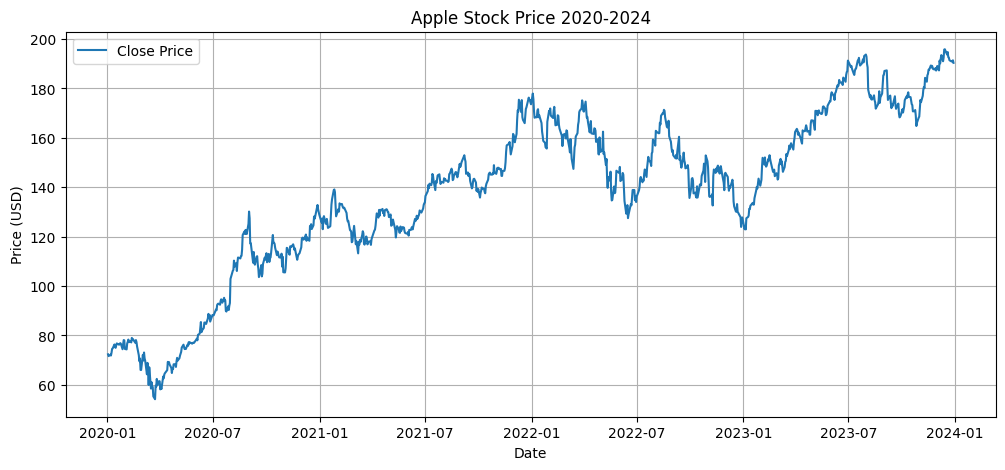

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df["Close"], label="Close Price")
plt.title("Apple Stock Price 2020-2024")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Data fetching and visualisation complete

In [9]:
df["MA7"] = df["Close"].rolling(window=7).mean()
df["MA21"] = df["Close"].rolling(window=21).mean()
df.head(2)

Price,Close,High,Low,Open,Volume,MA7,MA21
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,NaN,NaN
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800,NaN,NaN


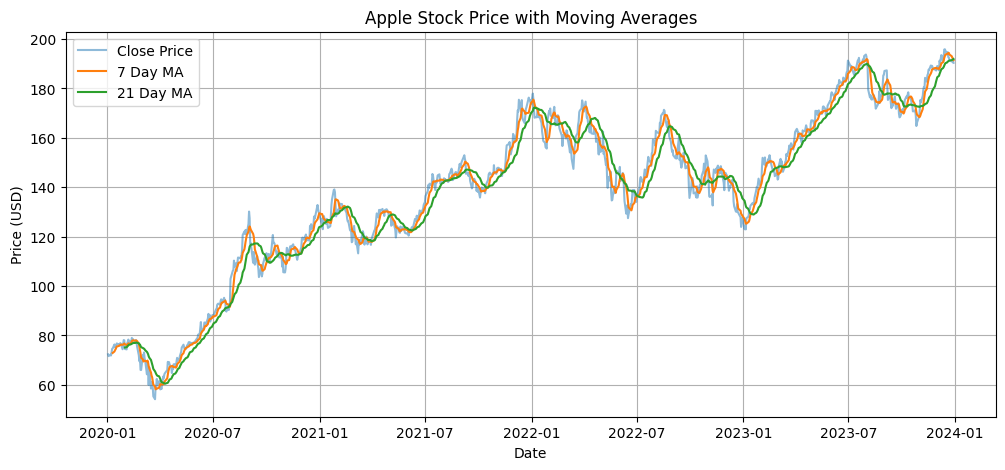

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df["Close"], label="Close Price", alpha=0.5)
plt.plot(df["MA7"], label="7 Day MA")
plt.plot(df["MA21"], label="21 Day MA")
plt.title("Apple Stock Price with Moving Averages")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
df["Volatility"] = df["Close"].rolling(7).std()
df.head(10)

Price,Close,High,Low,Open,Volume,MA7,MA21,Volatility
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,NaN,NaN,NaN
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800,NaN,NaN,NaN
2020-01-06,72.201393,72.239927,70.503531,70.753999,118387200,NaN,NaN,NaN
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,NaN,NaN,NaN
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,NaN
2020-01-09,74.568787,74.761449,73.742735,73.993195,170108400,NaN,NaN,NaN
2020-01-10,74.737381,75.300934,74.236454,74.802410,140644800,72.907389,NaN,1.269642
2020-01-13,76.334084,76.360579,74.934851,75.052863,121532000,73.478850,NaN,1.770088


In [12]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df["Target"].value_counts()

Target
1    528
0    478
Name: count, dtype: int64

In [ ]:
# Feature engineering complete - added MA7, MA21, Volatility and Target

In [14]:
train = df.loc["2020-01-01":"2022-12-31"]
test = df.loc["2023-01-01":"2024-01-01"]
print(train.shape)
print(test.shape)

(756, 9)
(250, 9)


In [15]:
X_train = train[["MA7", "MA21", "Volatility"]]
y_train = train["Target"]
X_test = test[["MA7", "MA21", "Volatility"]]
y_test = test["Target"]
print(X_train.shape)
print(X_test.shape)

(756, 3)
(250, 3)
